In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit
from uncertainties import *

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim = s.sim()
sim.ls_order = 2
sim.get_f()

sim.w0r = 31.52*1e-6
sim.r_sp = .0755
sim.r_pi = .0016
sim.w0b = 30.0*1e-6
sim.b_sp = .3355
sim.b_pi = .329

In [3]:
def analyticNormalDecay(t_bank, t_pi, σ = 4900.840919815411, tau = 0.0016786):
    Ω = np.pi/t_pi
    #Rabi flopping, weighted average over normally distributed qubit error
    δ_bank = np.linspace(-3*σ, 3*σ, 30)
    weight_bank = np.exp(-(δ_bank**2)/(2*(σ**2)))/np.sum(np.exp(-(δ_bank**2)/(2*(σ**2))))
    p = np.zeros(len(t_bank))
    for i in range(len(δ_bank)):
        p_temp = ((Ω**2)/(Ω**2 + δ_bank[i]**2))*(np.sin(t_bank*((Ω**2 +δ_bank[i]**2)**.5)/2)**2)*weight_bank[i]
        p = p + p_temp
    return .5 + .5*np.exp(-t_bank/tau)*(2*p - 1)

t_bank = np.linspace(10*1e-6,300e-6,10)
t_bank = np.logspace(1, np.log10(300), 25)*1e-6

inf_decoherence = np.array(())
inf_decoherence_opt = np.array(())

for t_pi in t_bank:
    p = analyticNormalDecay(t_bank,t_pi)

    inf_decoherence = np.append(inf_decoherence, 1-max(p))
    
    p = analyticNormalDecay(t_bank,t_pi, σ = 5, tau = .577)
    inf_decoherence_opt = np.append(inf_decoherence_opt, 1-max(p))

C:\Users\ions\Miniconda3\envs\qsim\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 960 (\N{GREEK SMALL LETTER PI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


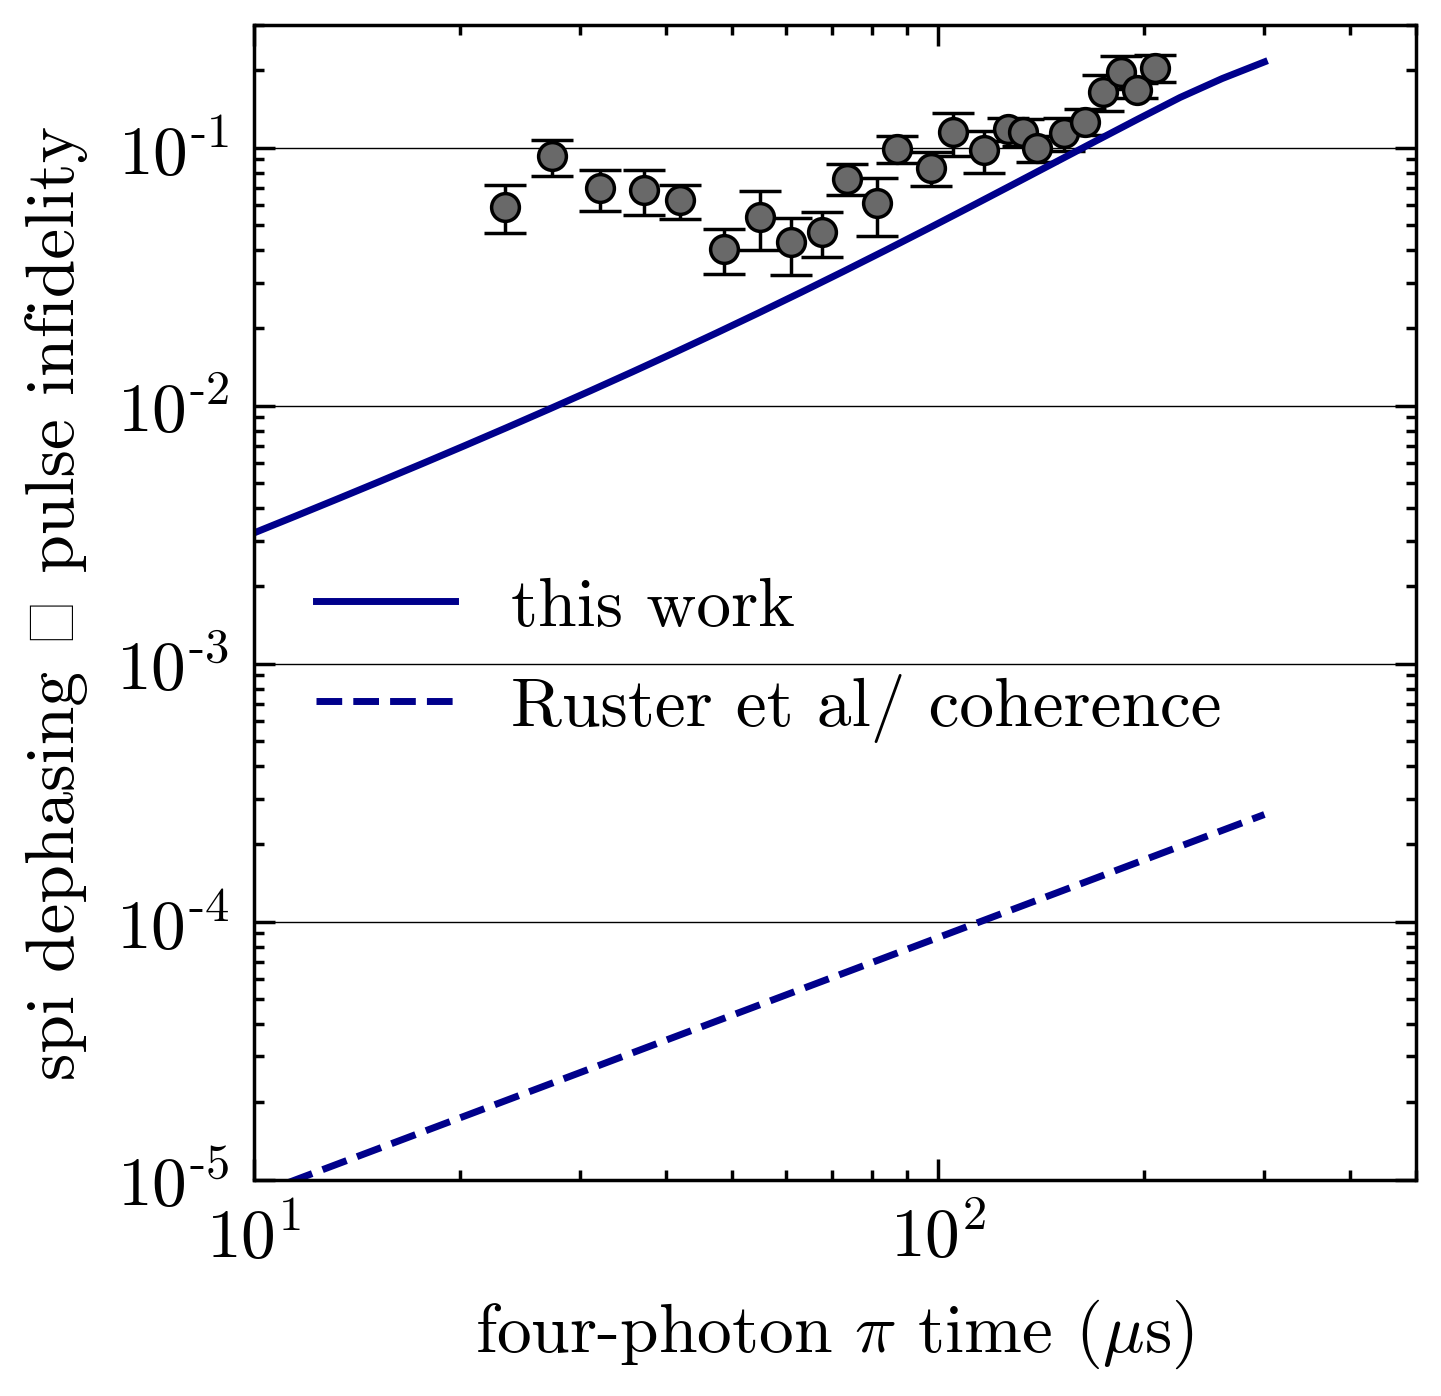

In [4]:
with plt.style.context(['science','no-latex']):
    # plt.rcParams["font.family"] = "Times New Roman"
    plt.figure(figsize = (3,3), dpi = 500)
    plt.errorbar(sim.tpi_4*1e6, 1-sim.fid_4, yerr = sim.δfid_4,marker = '.',
                 ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .5, 
                 ls='none', markersize=8, capsize=3, elinewidth = .5,markerfacecolor='dimgrey')
    xtick_positions = [1, 2, 3, 4, 5,6,7, 8,9,10]
    xtick_labels = ['1', '2', '','4', '','','', '8','','']
    plt.plot(t_bank*1e6,inf_decoherence,color='darkblue',label = 'this work')
    plt.plot(t_bank*1e6,inf_decoherence_opt,color='darkblue',label = 'Ruster et al/ coherence', linestyle = '--')
    plt.grid(which = 'major',color = 'black',linewidth = 0.2, axis = 'y')
    plt.ylabel('spi dephasing π pulse infidelity')
    plt.xlabel(r'four-photon $\pi$ time ($\mu$s)')
    plt.yscale('log')
    plt.xscale('log')
    plt.legend(loc = 'center left', bbox_to_anchor = (0,.45))
    plt.xlim(10, 500)
    plt.ylim(1e-5, .3)
    plt.show()

## pulse shaped intermediate state population

In [5]:
def inv_parabola(t, t0, y0, m):
    return m*((t- t0)**2) + y0

def fit_inv_parabola(x_data, y_data, p0_guess, bnds):
    popt, pcov = curve_fit(inv_parabola, x_data, y_data, p0 = p0_guess, bounds = bnds)
    error = np.sqrt(np.diag(pcov))
    return popt, error

In [6]:
sim4 = s.sim(PS_power = 4)

sim4.Pr = .195
sim4.Pb = .180
sim4.F_states = True
sim4.get_rabi_frequencies()
sim4.get_f()
sim4.b_pi = .33
sim4.b_sp = .373

f_bank4 = np.array(())
δf_bank4 = np.array(())

t_bank4 = np.array(())
δt_bank4 = np.array(())

tpi_bank4 = np.array(())

infs4 = []
ts4 = []
ps4 = []

In [7]:
t_bank = np.logspace(np.log10(15), np.log10(200), 25)*1e-6
# t_bank = np.logspace(np.log10(15), np.log10(100), 5)*1e-6
c = .2*17e-6
Pb_bank = c/t_bank

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

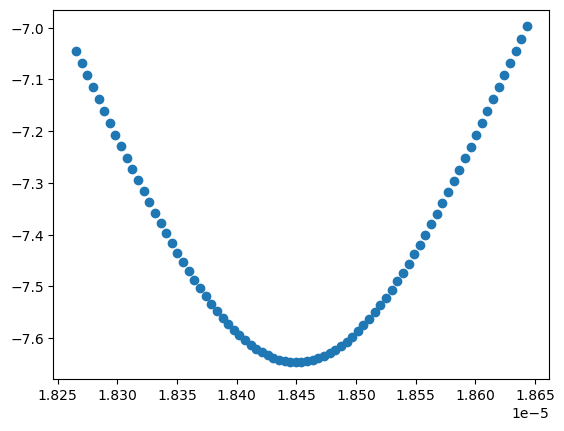

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

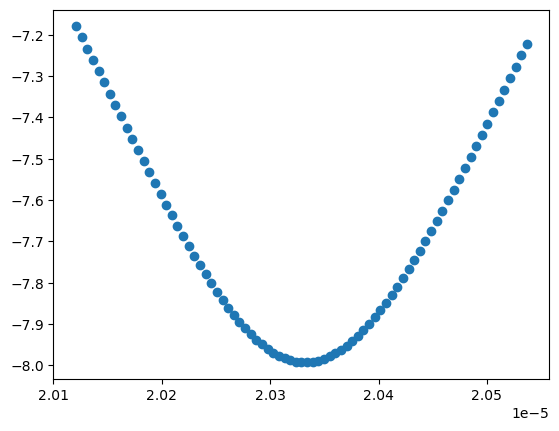

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

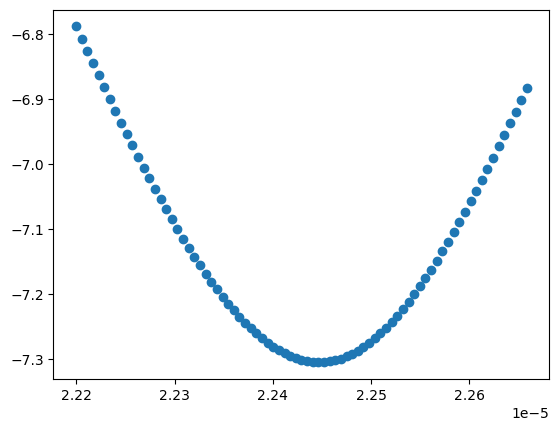

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

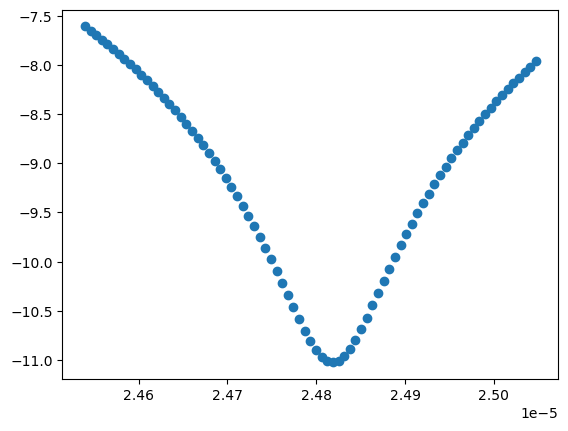

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
t_true4 = np.array(())
inf4 = np.array(())

for Pb in Pb_bank:
    sim4.ϵ = 0
    sim4.Pb = Pb
    sim4.power_scaling(np.array([Pb]))
    w_bank4 = [1.25]
    sim4.power_scaling_PS(w_bank4, np.pi/sim4.Ω_num_bank[0], scan = True)

    ind = np.argmax(sim4.fid_bank[0])
    t_true4 = np.append(t_true4, sim4.t_final_bank[0][ind])
    inf4 = np.append(inf4, (1-sim4.fid_bank[0][ind]))

    plt.figure()
    plt.scatter(sim4.t_final_bank[0], np.log((1-sim4.fid_bank[0])))
    plt.show()

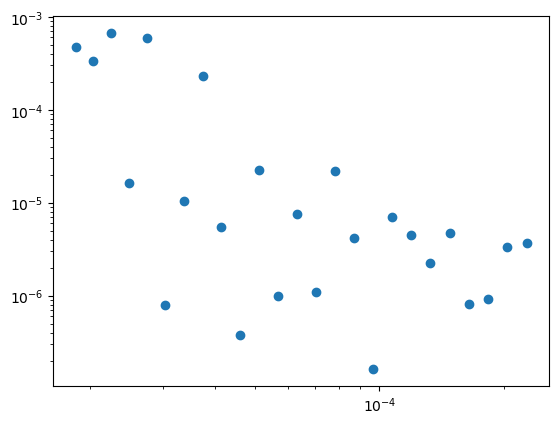

In [12]:
plt.scatter(t_true4, inf4)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [17]:
inf4

array([4.77576263e-04, 3.37945788e-04, 6.72317877e-04, 1.63303875e-05,
       5.85439731e-04, 7.90037621e-07, 1.03552810e-05, 2.29331596e-04,
       5.40834143e-06, 3.75298010e-07, 2.26727999e-05, 9.84674815e-07,
       7.50188705e-06, 1.08089663e-06, 2.19401995e-05, 4.17786483e-06,
       1.62662862e-07, 7.07236695e-06, 4.50263449e-06, 2.23926048e-06,
       4.66760647e-06, 8.11380772e-07, 9.11327216e-07, 3.36157144e-06,
       3.66946382e-06])

In [18]:
sim2 = s.sim(PS_power = 2)

sim2.Pr = .195
sim2.Pb = .180
sim2.F_states = True
sim2.get_rabi_frequencies()
sim2.get_f()
sim2.b_pi = .33
sim2.b_sp = .373

f_bank2 = np.array(())
δf_bank2 = np.array(())

t_bank2 = np.array(())
δt_bank2 = np.array(())

tpi_bank2 = np.array(())

infs2 = []
ts2 = []
ps2 = []

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

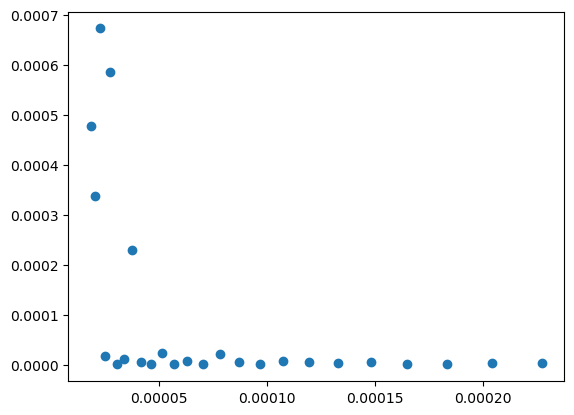

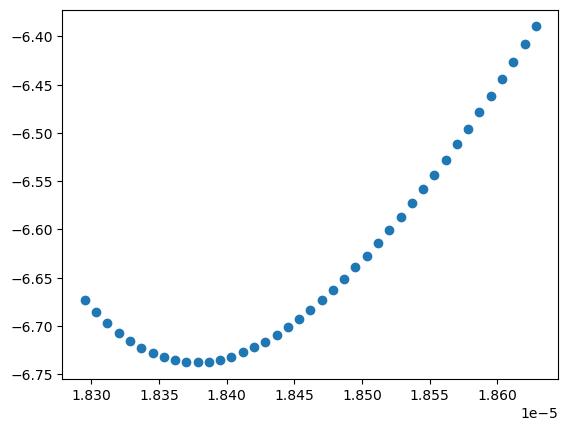

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

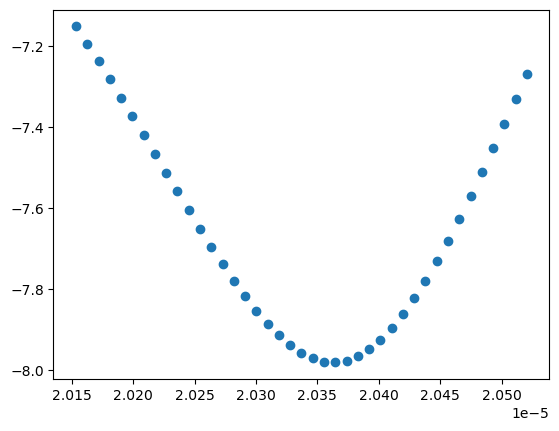

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

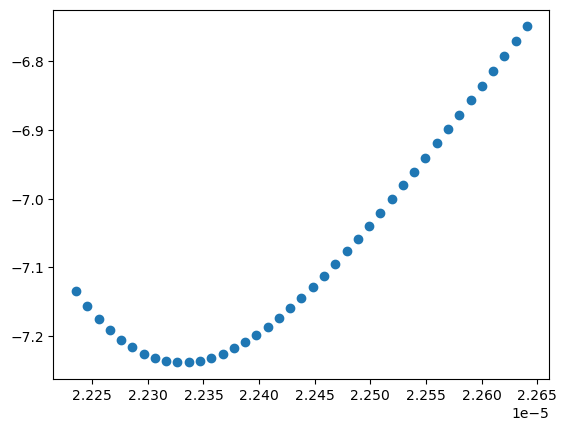

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

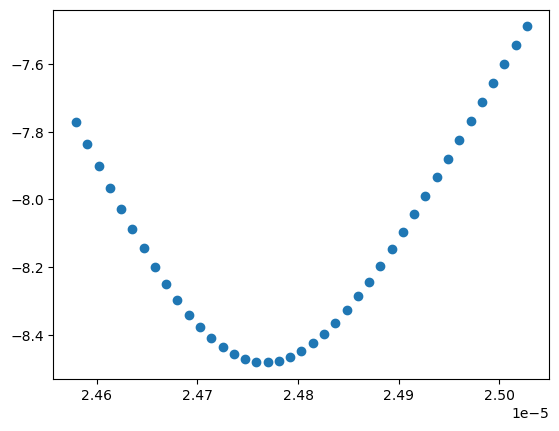

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

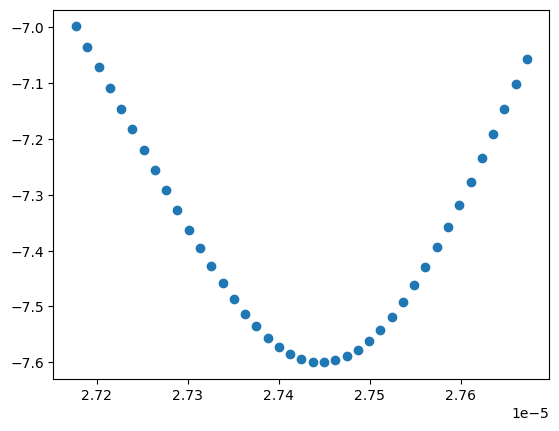

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 132.14 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 132.14 mW:   0%|          | 0/40 [00:00<?, ?it/s]

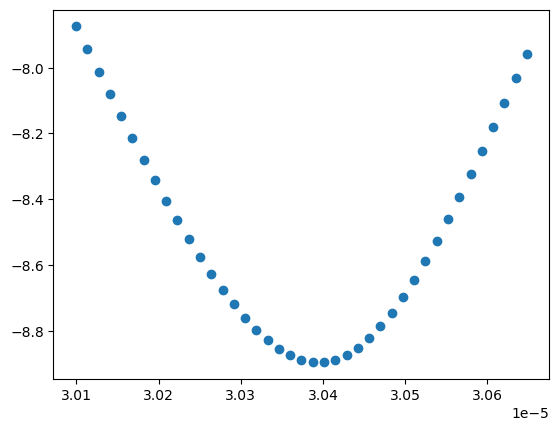

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 118.62 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 118.62 mW:   0%|          | 0/40 [00:00<?, ?it/s]

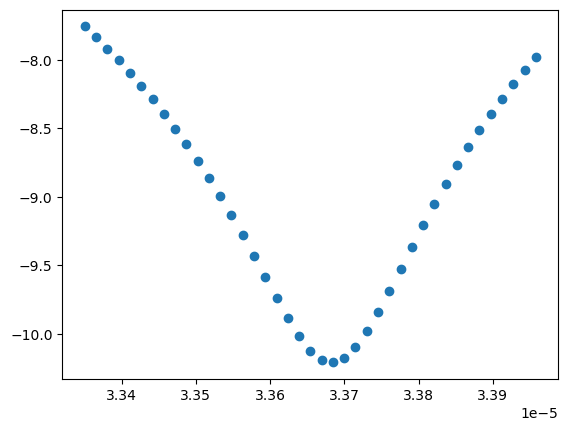

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 106.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 106.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

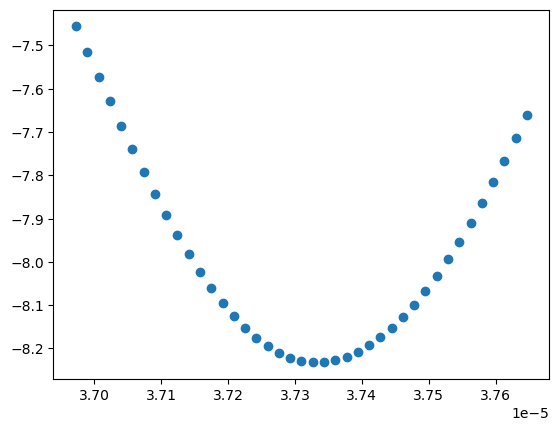

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 95.59 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 95.59 mW:   0%|          | 0/40 [00:00<?, ?it/s]

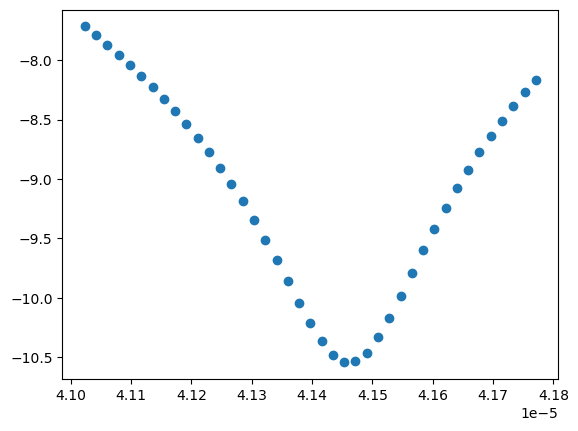

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 85.81 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 85.81 mW:   0%|          | 0/40 [00:00<?, ?it/s]

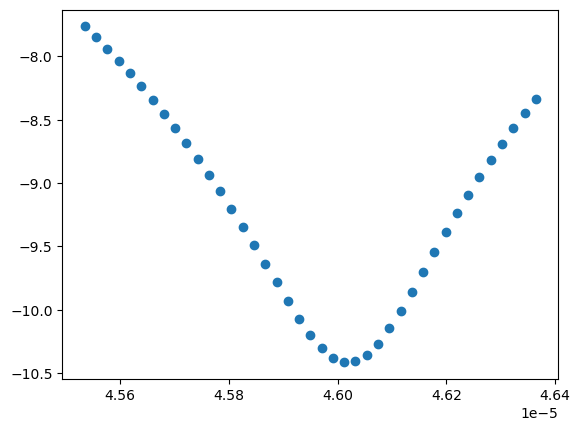

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 77.03 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 77.03 mW:   0%|          | 0/40 [00:00<?, ?it/s]

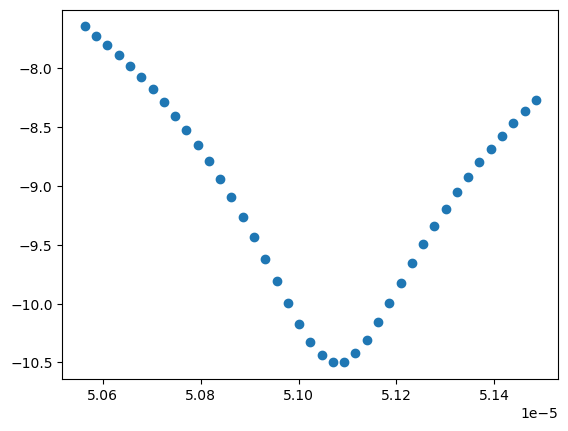

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 69.15 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 69.15 mW:   0%|          | 0/40 [00:00<?, ?it/s]

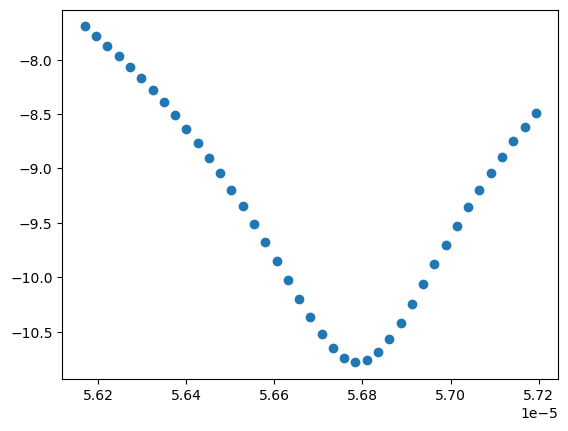

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 62.08 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 62.08 mW:   0%|          | 0/40 [00:00<?, ?it/s]

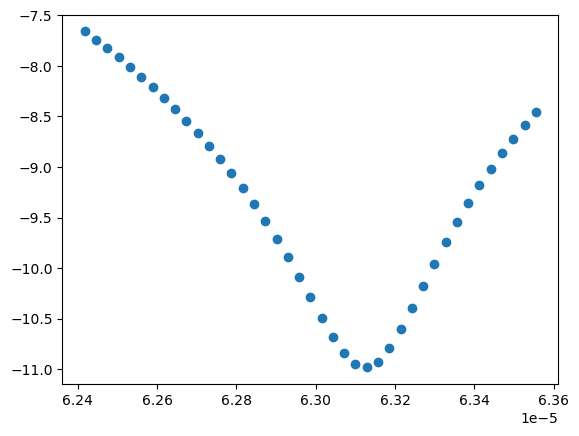

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 55.72 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 55.72 mW:   0%|          | 0/40 [00:00<?, ?it/s]

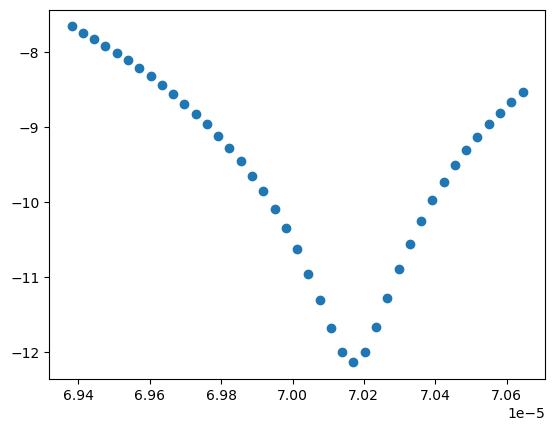

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 50.02 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 50.02 mW:   0%|          | 0/40 [00:00<?, ?it/s]

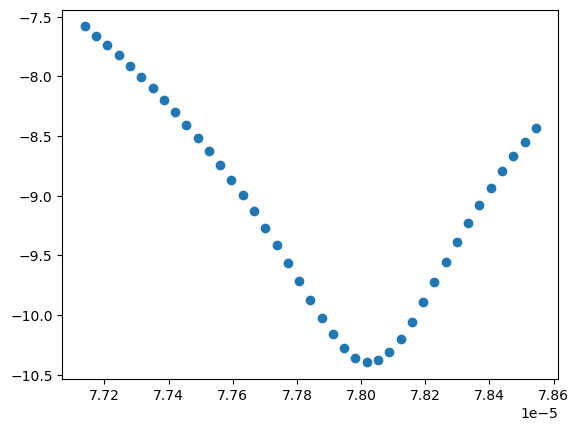

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 44.91 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 44.91 mW:   0%|          | 0/40 [00:00<?, ?it/s]

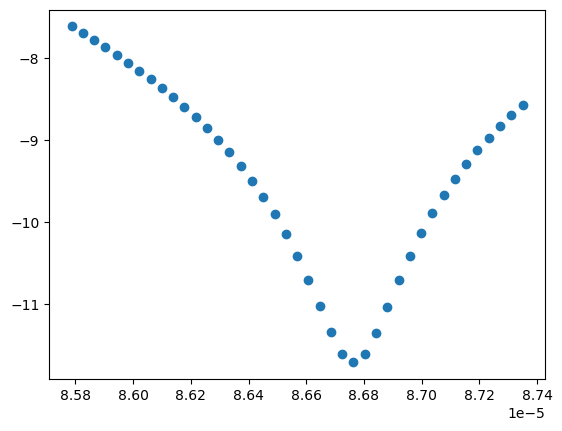

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 40.31 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 40.31 mW:   0%|          | 0/40 [00:00<?, ?it/s]

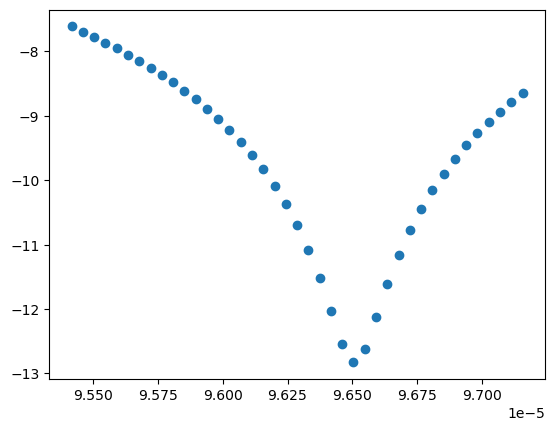

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 36.19 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 36.19 mW:   0%|          | 0/40 [00:00<?, ?it/s]

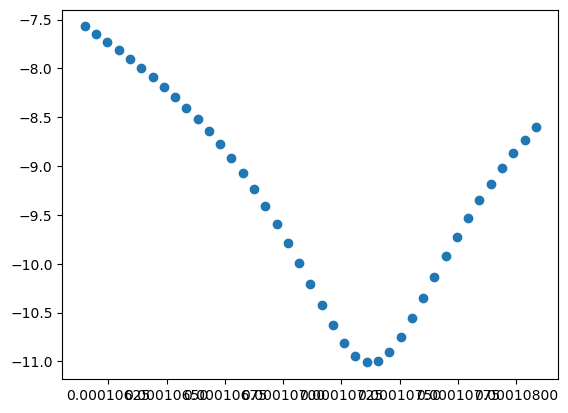

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 32.49 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 32.49 mW:   0%|          | 0/40 [00:00<?, ?it/s]

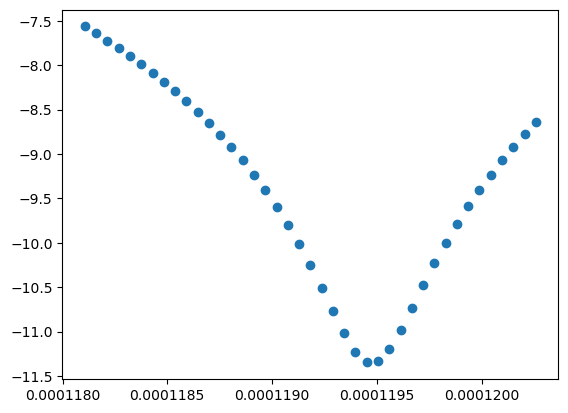

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 29.16 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 29.16 mW:   0%|          | 0/40 [00:00<?, ?it/s]

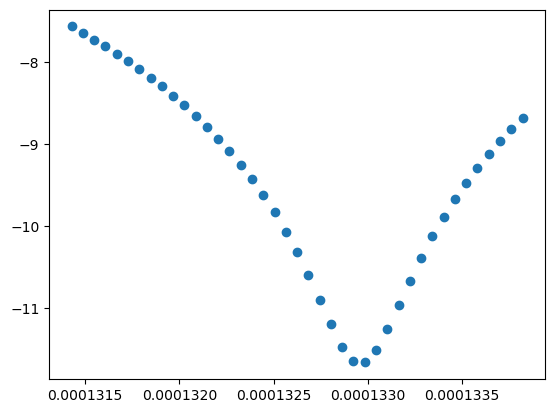

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 26.18 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 26.18 mW:   0%|          | 0/40 [00:00<?, ?it/s]

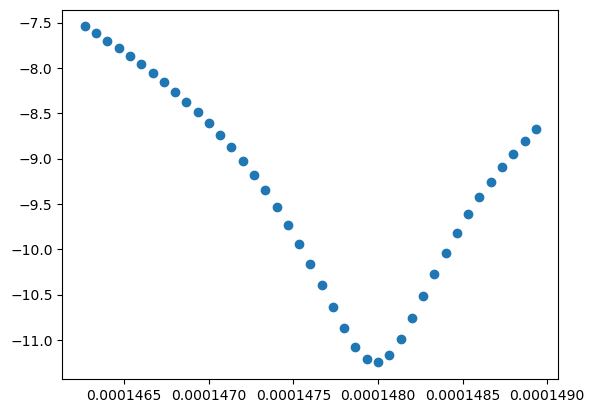

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 23.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 23.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

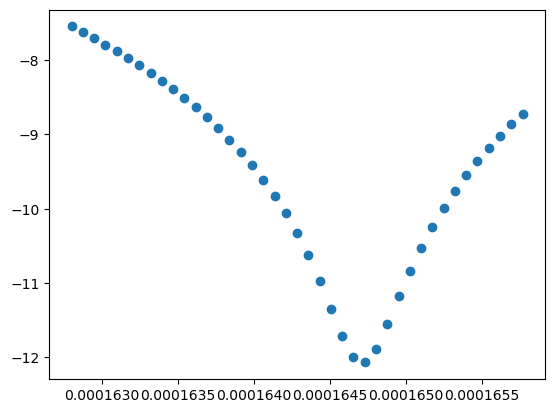

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 21.1 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 21.1 mW:   0%|          | 0/40 [00:00<?, ?it/s]

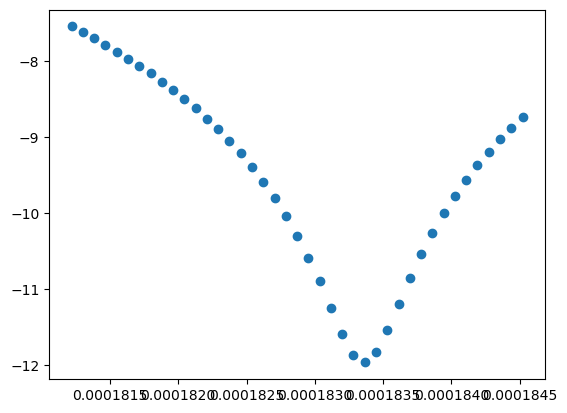

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 18.94 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 18.94 mW:   0%|          | 0/40 [00:00<?, ?it/s]

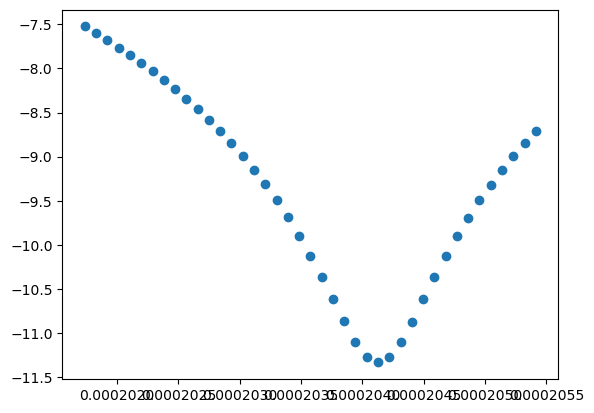

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 17.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 17.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

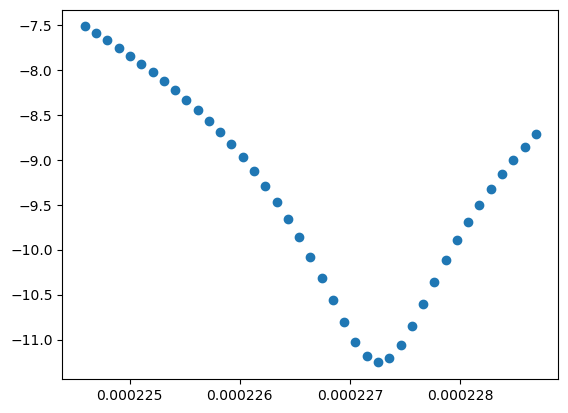

In [19]:
t_true2 = np.array(())
inf2 = np.array(())

for Pb in Pb_bank:
    sim2.ϵ = 0
    sim2.Pb = Pb
    sim2.power_scaling(np.array([Pb]))
    w_bank2 = [1.25]
    sim2.power_scaling_PS(w_bank2, np.pi/sim2.Ω_num_bank[0], scan = True)

    ind = np.argmax(sim2.fid_bank[0])
    t_true2 = np.append(t_true2, sim2.t_final_bank[0][ind])
    inf2 = np.append(inf2, (1-sim2.fid_bank[0][ind]))

    plt.figure()
    plt.scatter(sim2.t_final_bank[0], np.log((1-sim2.fid_bank[0])))
    plt.show()

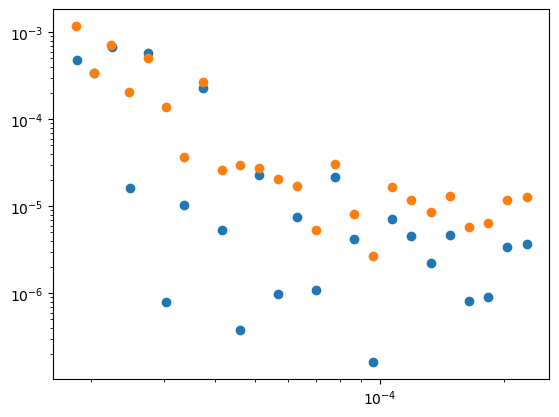

In [25]:
plt.scatter(t_true4, inf4)
plt.scatter(t_true2, inf2)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [26]:
t_true4

array([1.84543759e-05, 2.03288632e-05, 2.24520243e-05, 2.48187796e-05,
       2.74559599e-05, 3.04082599e-05, 3.36923500e-05, 3.73710976e-05,
       4.14652626e-05, 4.60252136e-05, 5.11340937e-05, 5.68039123e-05,
       6.31222253e-05, 7.01638650e-05, 7.80494234e-05, 8.67994003e-05,
       9.65437567e-05, 1.07402442e-04, 1.19500604e-04, 1.32978689e-04,
       1.47994298e-04, 1.64722227e-04, 1.83357784e-04, 2.04118476e-04,
       2.27244669e-04])

In [27]:
inf4

array([4.77576263e-04, 3.37945788e-04, 6.72317877e-04, 1.63303875e-05,
       5.85439731e-04, 7.90037621e-07, 1.03552810e-05, 2.29331596e-04,
       5.40834143e-06, 3.75298010e-07, 2.26727999e-05, 9.84674815e-07,
       7.50188705e-06, 1.08089663e-06, 2.19401995e-05, 4.17786483e-06,
       1.62662862e-07, 7.07236695e-06, 4.50263449e-06, 2.23926048e-06,
       4.66760647e-06, 8.11380772e-07, 9.11327216e-07, 3.36157144e-06,
       3.66946382e-06])

In [28]:
t_true2

array([1.83784548e-05, 2.03645600e-05, 2.23266682e-05, 2.47697700e-05,
       2.74496332e-05, 3.03875435e-05, 3.36845863e-05, 3.73265655e-05,
       4.14532213e-05, 4.60118481e-05, 5.10701217e-05, 5.67840140e-05,
       6.31285428e-05, 7.01708874e-05, 7.80174122e-05, 8.67638004e-05,
       9.65041603e-05, 1.07358392e-04, 1.19451592e-04, 1.32984009e-04,
       1.48000220e-04, 1.64728819e-04, 1.83365120e-04, 2.04126644e-04,
       2.27253762e-04])

In [29]:
inf2

array([1.18542635e-03, 3.41805415e-04, 7.18815701e-04, 2.07109265e-04,
       5.00572446e-04, 1.36843432e-04, 3.69289820e-05, 2.66003065e-04,
       2.63227889e-05, 2.99406322e-05, 2.75595829e-05, 2.07712008e-05,
       1.70278365e-05, 5.35140281e-06, 3.05064767e-05, 8.14752582e-06,
       2.68350482e-06, 1.65313163e-05, 1.18054119e-05, 8.61075501e-06,
       1.30263521e-05, 5.73594156e-06, 6.35079429e-06, 1.19456773e-05,
       1.29334582e-05])

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 226.67 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[0.00047749]
0.9995225144503193


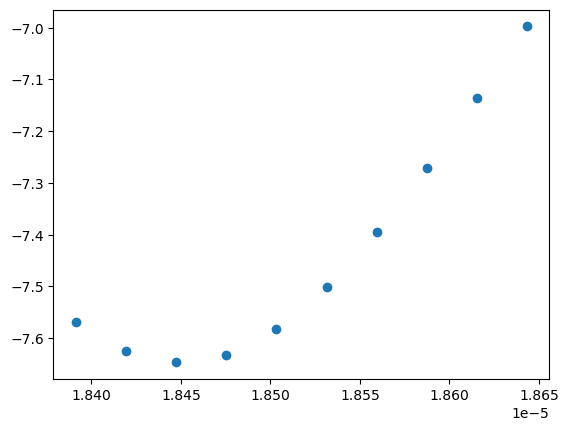

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 203.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[0.00033897]
0.9996610279789726


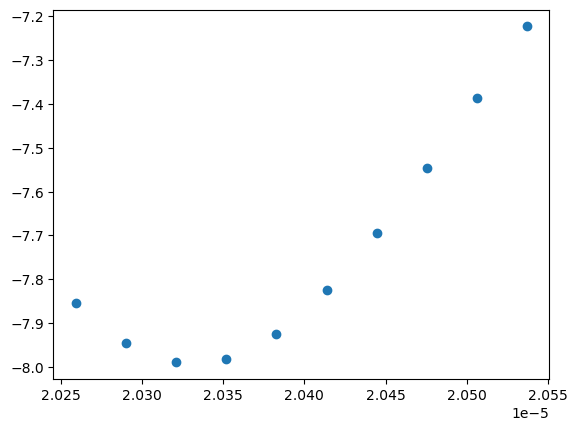

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 182.66 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[0.00067257]
0.9993274276646171


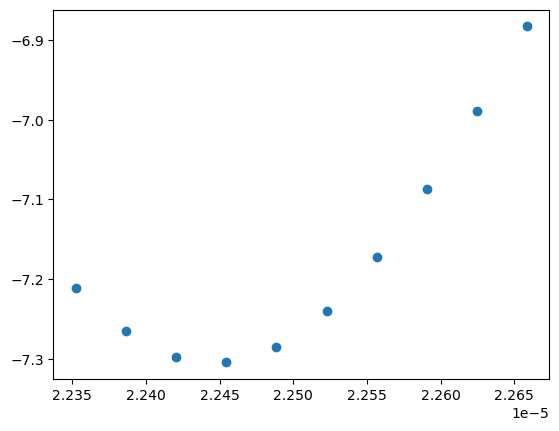

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 163.97 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.63967392e-05]
0.9999836032608296


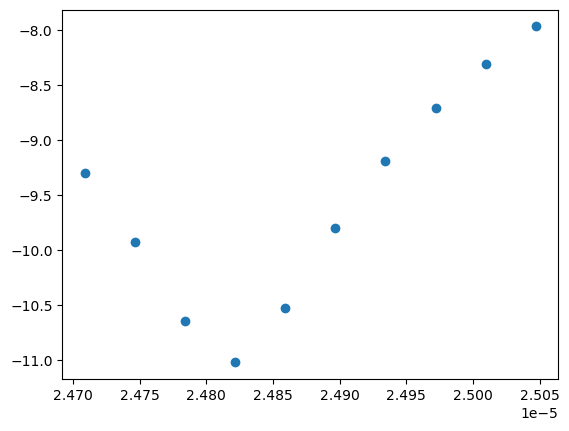

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 147.2 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[0.0005853]
0.9994147022046305


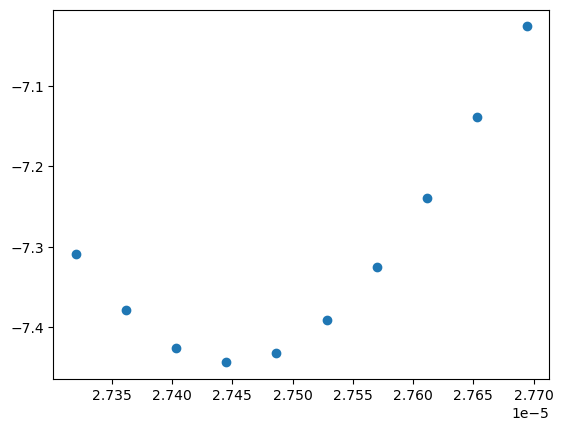

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 132.14 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 132.14 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.38372975e-06]
0.9999986162702463


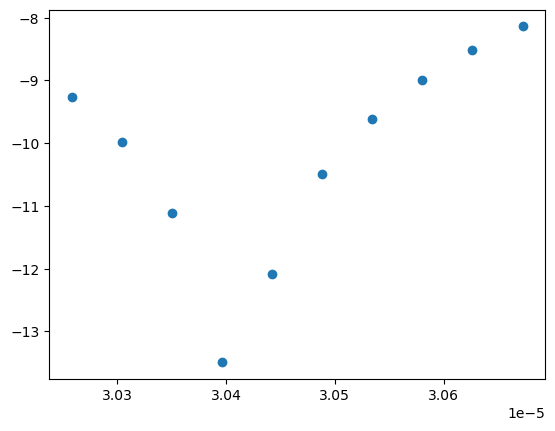

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 118.62 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 118.62 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.15717852e-05]
0.9999884282148181


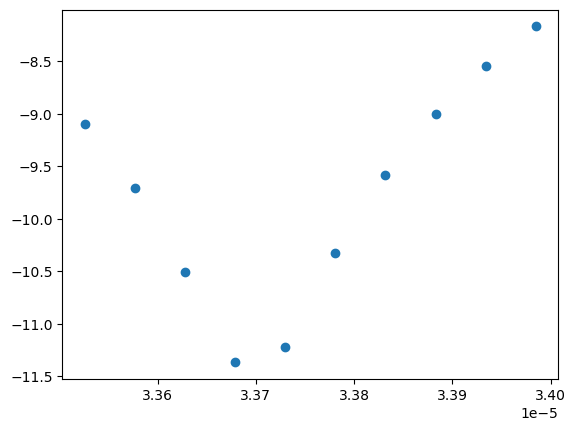

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 106.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 106.48 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[0.00023117]
0.999768826648079


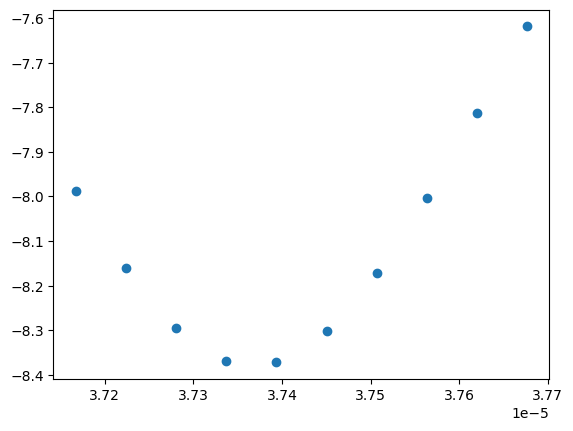

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 95.59 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 95.59 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[6.32922987e-06]
0.9999936707701272


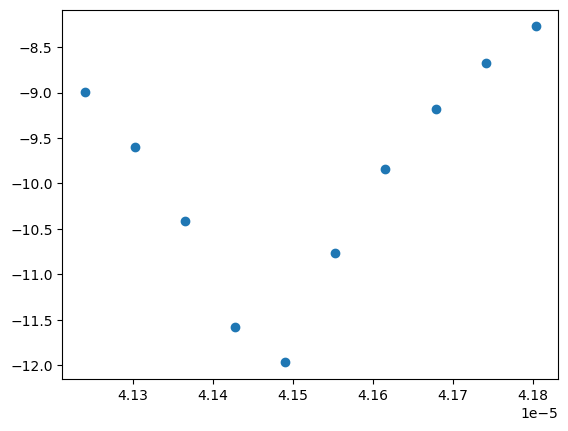

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 85.81 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 85.81 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[6.11307446e-07]
0.9999993886925543


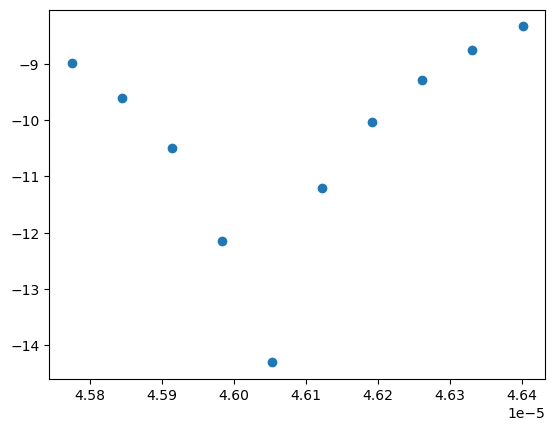

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 77.03 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 77.03 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[2.27962382e-05]
0.9999772037618361


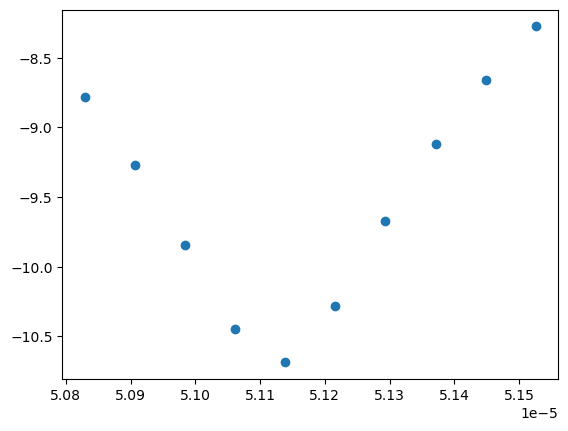

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 69.15 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 69.15 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.02350823e-06]
0.9999989764917664


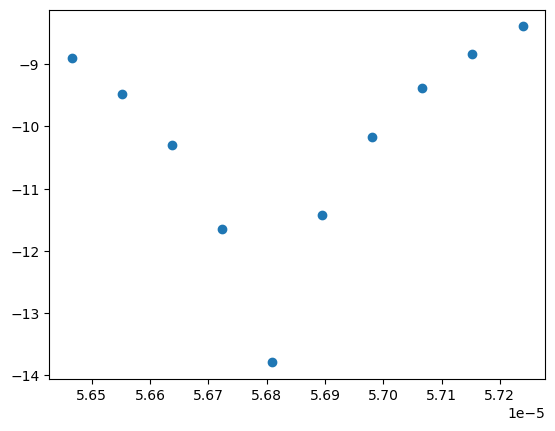

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 62.08 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 62.08 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[7.46726126e-06]
0.999992532738741


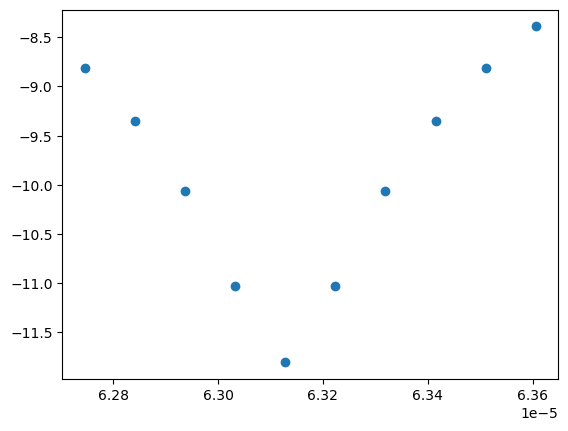

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 55.72 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 55.72 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[9.80198352e-07]
0.9999990198016475


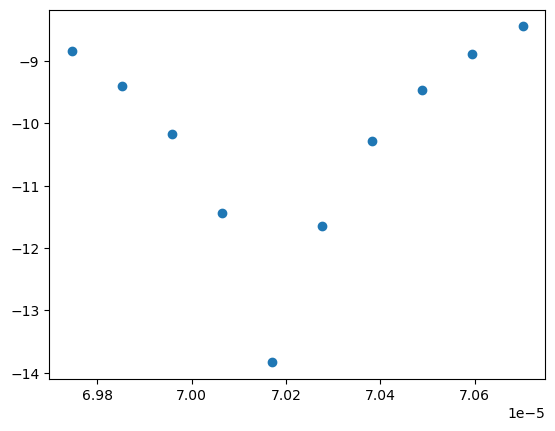

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 50.02 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 50.02 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[2.18107221e-05]
0.9999781892778727


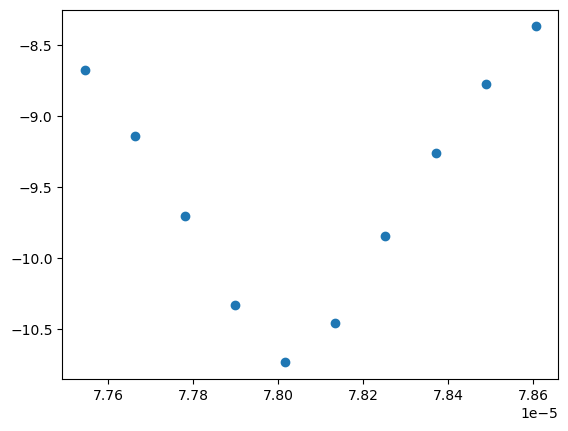

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 44.91 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 44.91 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[4.21220709e-06]
0.9999957877929079


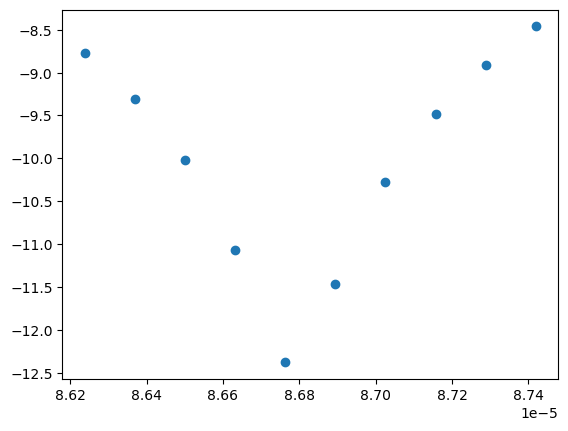

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 40.31 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 40.31 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[4.40400417e-07]
0.9999995595995831


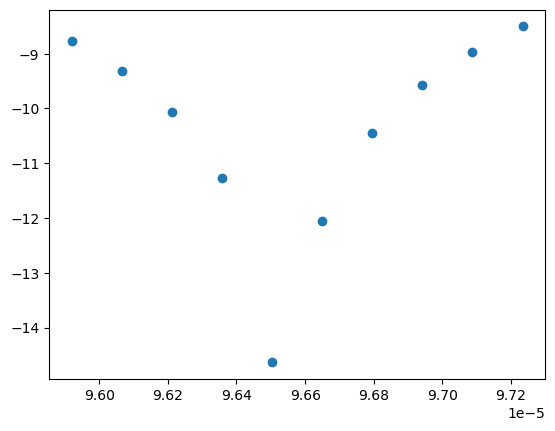

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 36.19 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 36.19 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[7.51845023e-06]
0.9999924815497678


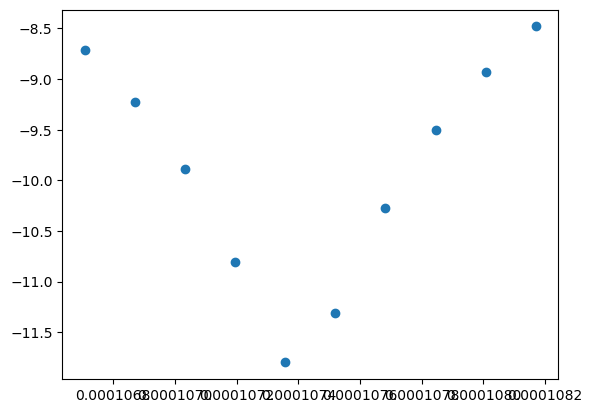

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 32.49 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 32.49 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[5.08987763e-06]
0.9999949101223732


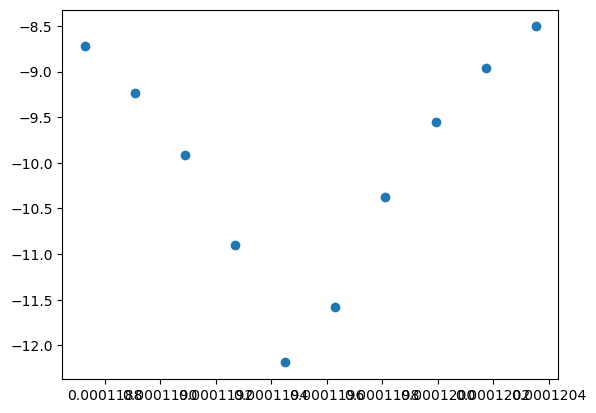

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 29.16 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 29.16 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[2.9601378e-06]
0.9999970398621955


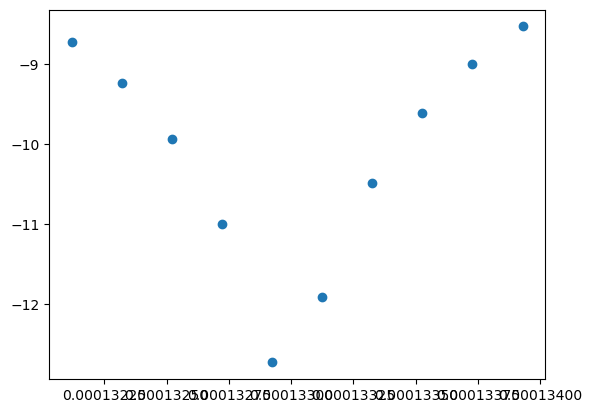

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 26.18 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 26.18 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[5.49989656e-06]
0.9999945001034399


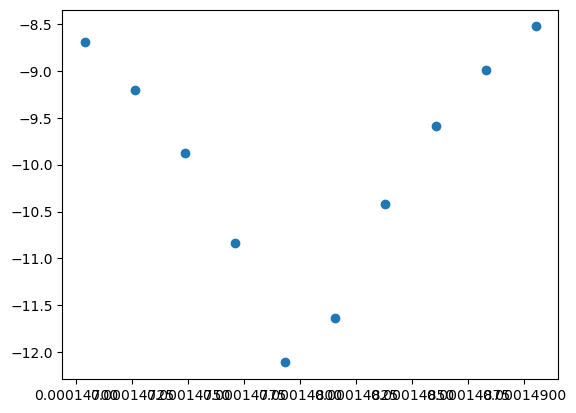

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 23.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 23.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.74779133e-06]
0.999998252208674


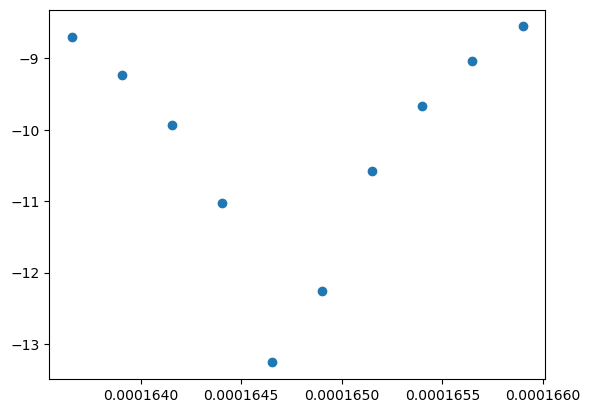

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 21.1 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 21.1 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[1.92964425e-06]
0.9999980703557486


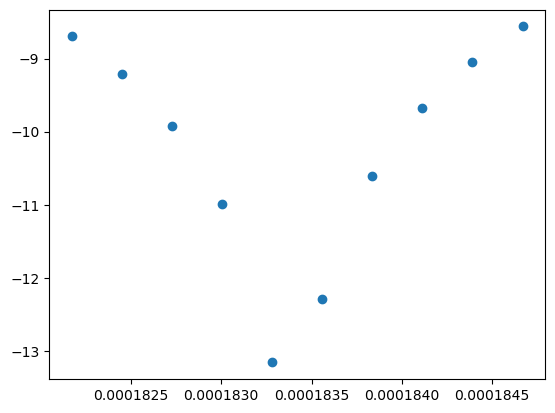

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 18.94 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 18.94 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[4.45092082e-06]
0.9999955490791781


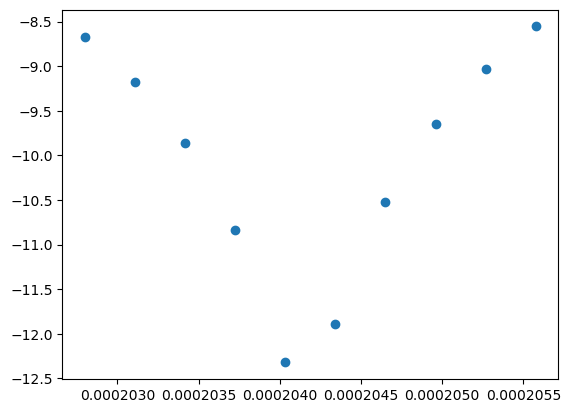

power scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 17.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

PS scan progress:   0%|          | 0/1 [00:00<?, ?it/s]

spectroscopy, Pb = 17.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

[4.8348032e-06]
0.9999951651968008


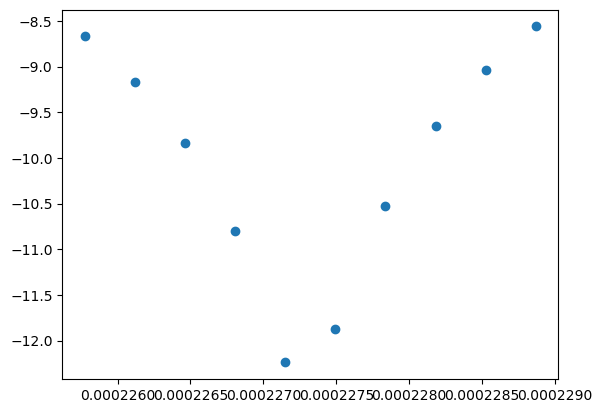

In [15]:
for Pb in Pb_bank:
    sim4.ϵ = 0
    sim4.Pb = Pb
    sim4.power_scaling(np.array([Pb]))
    w_bank4 = [1.25]
    tpi_bank4 = np.append(tpi_bank4, np.pi/sim4.Ω_num_bank[0])
    
    sim4.power_scaling_PS(w_bank4, np.pi/sim4.Ω_num_bank[0], scan = True)

    t_true4 = np.array(())
    δt_true4 = np.array(())
    inf4 = np.array(())
    δinf4 = np.array(())

    for i in range(len(sim4.t_bank)):
        
        ind = np.argmax(sim4.fid_bank[i])
        t_true = np.append(t_true, t_final_bank[i][ind])
        inf4 = np.append(inf4, )
        
        
        ind = int(len(sim4.t_final_bank[i])/2 - 0.5)
        
        x4 = sim4.t_final_bank[i]
        y_log4 = np.log(1 - sim4.fid_bank[i])
            
        # p0 = [x4[ind], y_log4[ind], 2e13]
        # bounds = ((0, -20, 1e10), (1, -2, 1e15))
        
        infs4.append(1 - sim4.fid_bank[i])
        ts4.append(x4)
        
        # try:
            # params4, error4 = fit_inv_parabola(x4, y_log4, p0, bounds)

            # f4 = np.append(f4, 1-np.exp(params4[1]))
            # δf4 = np.append(δf4, error4[1]*np.exp(params4[1]))
            
        f4 = np.append(f4, (1-max(sim4.fid_bank[i])))
        print(f4)
        print(max(sim4.fid_bank[i]))
        plt.figure()
        plt.scatter(x4, y_log4)
        plt.show()
            

    f_bank4 = np.append(f_bank4, f4)
    δf_bank4 = np.append(δf_bank4, δf4)

    t_bank4 = np.append(t_bank4, t_true4)
    δt_bank4 = np.append(δt_bank4, δt_true4)

In [ ]:
t_true4 = np.array(())
δt_true4 = np.array(())
f4 = np.array(())
δf4 = np.array(())

for i in range(len(sim4.t_bank)):

    ind = int(len(sim4.t_final_bank[i])/2 - 0.5)

    x4 = sim4.t_final_bank[i]
    y_log4 = np.log(1 - sim4.fid_bank[i])

    # p0 = [x4[ind], y_log4[ind], 2e13]
    # bounds = ((0, -20, 1e10), (1, -2, 1e15))

    infs4.append(1 - sim4.fid_bank[i])
    ts4.append(x4)

    # try:
        # params4, error4 = fit_inv_parabola(x4, y_log4, p0, bounds)

        # f4 = np.append(f4, 1-np.exp(params4[1]))
        # δf4 = np.append(δf4, error4[1]*np.exp(params4[1]))

    f4 = np.append(f4, (1-max(sim4.fid_bank[i])))
    print(f4)

    # t_true4 = np.append(t_true4, params4[0])
    # δt_true4 = np.append(δt_true4, error4[0])

    # print(1-np.exp(params4[1]))
    print(max(sim4.fid_bank[i]))
    # print(error4[1]*np.exp(params4[1]))

    # x_fit = np.linspace(min(x4), max(x4), 100)
    # y_fit = inv_parabola(x_fit, *params4)
    plt.figure()
    plt.scatter(x4, y_log4)
    # plt.plot(x_fit, y_fit)
    plt.show()


    # ps4.append(params4)
    # except:
    #     f4 = np.append(f4, -1)
    #     δf4 = np.append(δf4, -1)
    #     t_true4 = np.append(t_true4, -1)
    #     δt_true4 = np.append(δt_true4, -1)

f_bank4 = np.append(f_bank4, f4)
δf_bank4 = np.append(δf_bank4, δf4)

t_bank4 = np.append(t_bank4, t_true4)
δt_bank4 = np.append(δt_bank4, δt_true4)

In [39]:
sim4.fid_bank

[array([0.99982769, 0.99989596, 0.99994662, 0.99997969, 0.99999517,
        0.99999302, 0.99997327, 0.99993591, 0.99988105, 0.99980844])]

In [23]:
plt.scatter(t_bank*1e6, f_bank4)
plt.xscale('log')
plt.yscale('log')
plt.show()

ValueError: x and y must be the same size

In [24]:
len(tpi_bank4)

0

In [16]:
max(sim4.fid_bank[i])

0.9999951651968008

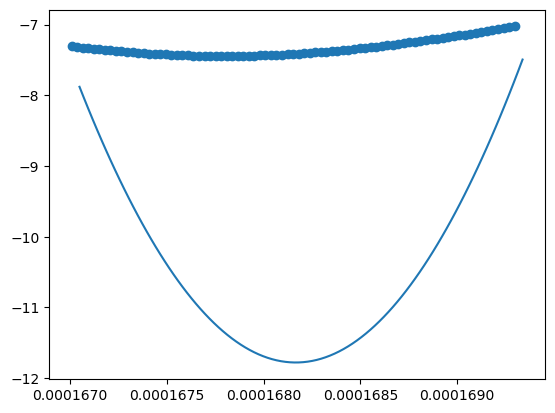

In [24]:
plt.figure()
plt.scatter(x4*6.113, y_log4)
plt.plot(x_fit, y_fit)
plt.show()
            

In [ ]:
sim2 = s.sim(PS_power = 2)

sim2.Pr = .195
sim2.Pb = .180
sim2.F_states = True
sim2.get_rabi_frequencies()
sim2.get_f()
sim2.b_pi = .33
sim2.b_sp = .373

f_bank2 = np.array(())
δf_bank2 = np.array(())

t_bank2 = np.array(())
δt_bank2 = np.array(())

tpi_bank2 = np.array(())

infs2 = []
ts2 = []
ps2 = []

In [ ]:
for Pb in Pb_bank:
    sim2.ϵ = 0
    sim2.power_scaling(np.array([Pb]))
    w_bank2 = np.array([1.25])
    tpi_bank2 = np.append(tpi_bank2, np.pi/sim2.Ω_num_bank[0])
    sim2.Pb = Pb
    sim2.power_scaling_PS(w_bank2, np.pi/sim2.Ω_num_bank[0], scan = True)

    t_true2 = np.array(())
    δt_true2 = np.array(())
    f2 = np.array(())
    δf2 = np.array(())

    for i in range(len(sim2.t_bank)):
        
        ind = int(len(sim2.t_final_bank[i])/2 - 0.5)
        
        x2 = sim2.t_final_bank[i]
        y_log2 = np.log(1 - sim2.fid_bank[i])
            
        p0 = [x2[ind], y_log2[ind], 2e13]
        bounds = ((0, -20, 1e10), (1, -2, 1e15))
        
        infs2.append(1 - sim2.fid_bank[i])
        ts2.append(x2)
        
        try:
            params2, error2 = fit_inv_parabola(x2, y_log2, p0, bounds)

            # f2 = np.append(f2, 1-np.exp(params2[1]))
            # δf2 = np.append(δf2, error2[1]*np.exp(params2[1]))
            
            f2 = np.append(1-max(sim2.fid_bank[i]))
            print(f2)
            
            t_true2 = np.append(t_true2, params2[0])
            δt_true2 = np.append(δt_true2, error2[0])
            
            print(1-np.exp(params2[1]))
            print(error2[1]*np.exp(params2[1]))
          
            x_fit = np.linspace(min(x2), max(x2), 100)
            y_fit = inv_parabola(x_fit, *params2)
            plt.figure()
            plt.scatter(x2, y_log2)
            plt.plot(x_fit, y_fit)
            plt.show()
            
            ps2.append(params2)
        except:
            f2 = np.append(f2, -1)
            δf2 = np.append(δf2, -1)
            t_true2 = np.append(t_true2, -1)
            δt_true2 = np.append(δt_true2, -1)

    f_bank2 = np.append(f_bank2, f2)
    δf_bank2 = np.append(δf_bank2, δf2)

    t_bank2 = np.append(t_bank2, t_true2)
    δt_bank2 = np.append(δt_bank2, δt_true2)

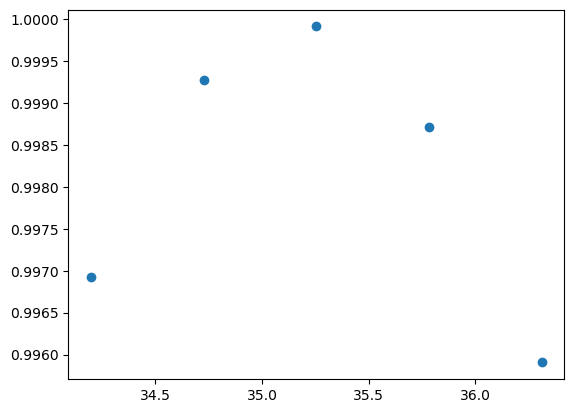

In [18]:
ind = 0
plt.scatter(sim2.t_final_bank[ind]*1e6, sim2.fid_bank[ind])
plt.show()

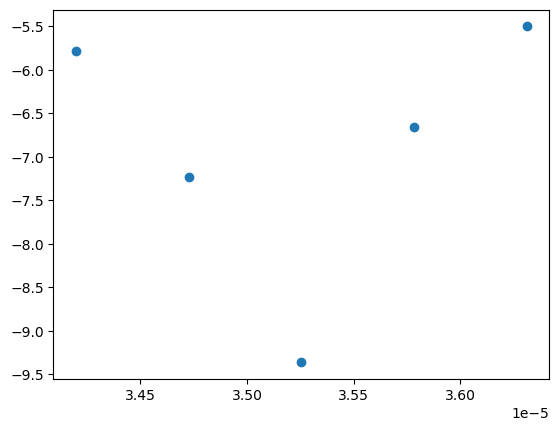

In [23]:
plt.scatter(x2, y_log2)
plt.show()

In [31]:
t_bank = np.logspace(1, np.log10(300), 25)

In [30]:
t_bank

array([ 10., 300.])

In [28]:
np.log10(300)

2.4771212547196626